<a href="https://colab.research.google.com/github/viviantram03/labb-1/blob/main/vizandstorytelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Overview and Data Loading
In this section, I load the dataset and the necessary libraries for analysis. The goal is to prepare the raw data for a deep dive into booking patterns and cancellation risks.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# ignore warning messages for a cleaner output
warnings.filterwarnings("ignore")

# load the dataset
df = pd.read_csv('hotel_bookings.csv')


##2. Feature Explanation

Before cleaning, it can be essential to understand the features (columns). Key variables include:



*   is_canceled: Our target variable (1 = canceled, 0 = not canceled).
*   lead_time: Days between booking and arrival.
*   adr = Average Daily Rate, representing the price per room per day.
*   market_segment: How the booking was made.
*   arrival_date_month: Useful for identifying seasonal trends







##3. Handling Missing Values

During the initial inspection, missing values were identified in four columns. My strategy for handling them is as follows:


*   Children: Missing values were replaced with 0, assuming that the absence of data indicates no children were part of the booking
*   Country: Missing entries were labeled as "Unknown" to maintain the integrity of the geographic analysis without mkaing assumptions about the origin.
*   Agent & Company: Missing IDs were replaced with 0, signifying that the booking was made independently without the involvement of a third-party agency or corporate entity.





In [ ]:
# fill missing 'children' with 0, 'country' with 'Unknown', and 'agent'/'company' with 0
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

##4. Data Conversion

To make the data more usable for plotting and calculation:
*   I converted children and agent IDs to integers.
*   The arrival_date_month was converted to an Ordered Categorical type. This is crucial because standard alphabetical sorting would put "April" before "January".




In [ ]:
# convert float columns to integers for cleaner data processing
df['children'] = df['children'].astype(int)
df['agent'] = df['agent'].astype(int)

# convert 'arrival_data_month' to an ordered categorical data type for correct plotting order
ordered_months = ["January", "February", "March", "April", "May", "June",
                  "July", "August", "September", "October", "November", "December"]
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=ordered_months, ordered=True)

##5. Data Aggregation

I created two new calculated columns:
1. total_stay: Sum of weekend and weeknight stays to see the full duration.
2. total_guests: Sum of adults, children, and babies to see the actual group size.

In [ ]:
# calculate total duration of stay and total number of guests booking
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']

##6. Feasibility Analysis
To ensure the dataset reflects realistic scenarios, I conducted a feasibility check on the guest counts. Any booking where the total_guests sum (adults + children + babies) resulted in 0 was removed, as a valid hotel reservation requires at least one occupant.

In [ ]:
original_shape = df.shape[0]

# filter out unfeasible bookings with 0 guests
df = df[df['total_guests'] > 0]

##8. Outlier Removal
The adr (Average Daily Rate) column contained extreme values that could heavily skew statistical averages and mislead the final narrative. I restricted the analysis to a realistic price range where 0≤adr<5000. This removes both negative values and extreme high-end anomalities, ensuring the visualizations represent the typical customer experience accurately.

In [ ]:
# filter out extreme outliers: keep only bookings with a valid average daily rate (ADR) between 0 and 5000
df = df[(df['adr'] >= 0) & (df['adr'] < 5000)]

new_shape = df.shape[0]
removed_rows = original_shape - new_shape

# print a summary of the removed outliers
print("--- Data Cleaning ---")
print(f"Original rows: {original_shape}")
print(f"Rows remaining: {new_shape}")
print(f"Removed rows: {removed_rows} ({(removed_rows/original_shape)*100:.2f}%)\n")

--- Data Cleaning ---
Original rows: 119390
Rows remaining: 119208
Removed rows: 182 (0.15%)



##7. Data Visualization (EDA)

In this section, I use five different charts to look at the data from a business perspective. These visualizations help us understand everything from seasonal trends to guest behavior and the risk of cancellations.

1. Overall Booking Status Distribution
This pie chart gives us the "big picture." It shows the percentage of bookings that were actually completed versus those that were canceled. Seeing that over one-third of bookings are canceled highlights a major challenge for the hotel's revenue.

2. Demand vs. Price per Month
This chart combines two things: the number of bookings (bars) and the average price (line) for each month. It shows us the "high season" and "low season." We can see if the hotel raises its prices when there are more guests, which is a key part of making a profit.

3. Lead Time vs. Cancellation Risk
Here, I look at how long in advance a guest makes a booking (Lead Time). The boxplot shows that guests who book very early are much more likely to cancel than those who book last minute. This helps the hotel predict which bookings are "risky."

4. Distribution of Stay Duration
This chart shows how many nights guests usually stay. By comparing City and Resort hotels, we can see a clear difference: City hotels are popular for short trips (1–3 nights), while Resort hotels are preferred for longer vacations.

5. Special Requests by Market Segment
Finally, this bar chart shows which types of customers make the most special requests (like asking for a twin bed or a high floor). For example, "Online Travel Agent" guests often ask for more, while "Aviation" guests rarely do. This helps the hotel plan how much staff is needed to provide good service.

##8. Outlier Removal
The adr (Average Daily Rate) column contained extreme values that could heavily skew statistical averages and mislead the final narrative. I restricted the analysis to a realistic price range where 0≤adr<5000. This removes both negative values and extreme high-end anomalities, ensuring the visualizations represent the typical customer experience accurately.

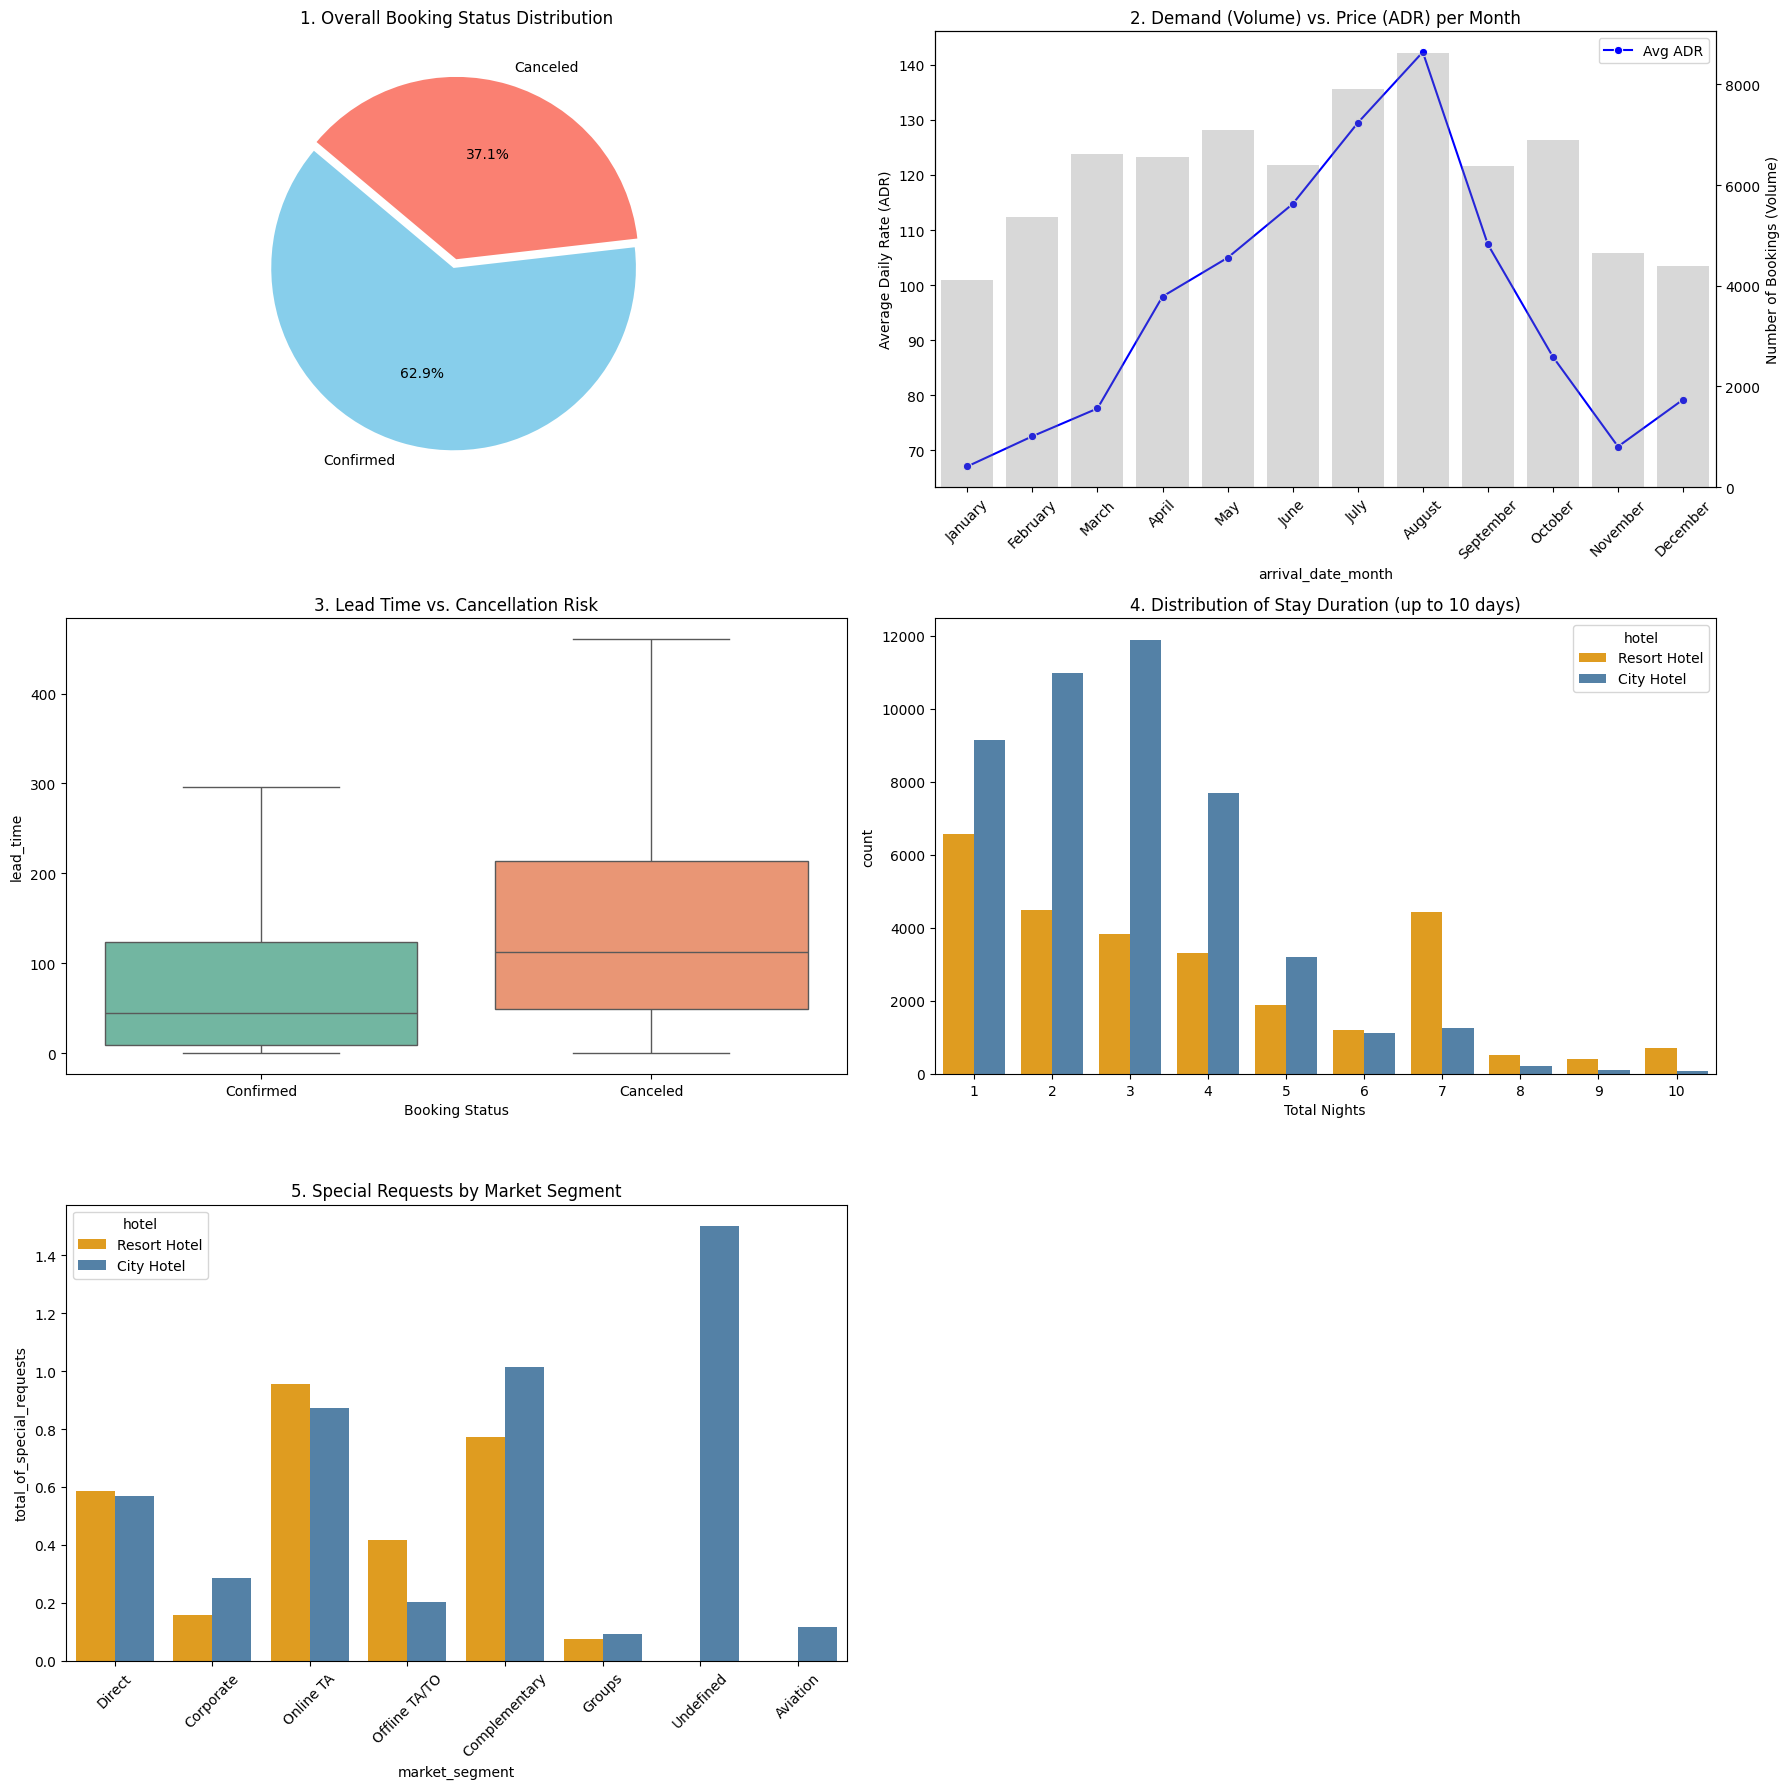

In [ ]:
# define simple color names for the hotels
hotel_colors = {'City Hotel': 'steelblue', 'Resort Hotel': 'orange'}

# set up the figure with 5 visualizations in a 3x2 grid
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# 1. distribution of booking status (showing the proportion of cancellations)
cancel_counts = df['is_canceled'].value_counts()
axes[0, 0].pie(cancel_counts, labels=['Confirmed', 'Canceled'], autopct='%1.1f%%',
                startangle=140, colors=['skyblue', 'salmon'], explode=(0.05, 0))
axes[0, 0].set_title('1. Overall Booking Status Distribution')

# 2. demand vs price per month (comparing volume of bookings with average adr)
monthly_data = df[df['is_canceled'] == 0].groupby('arrival_date_month', observed=True).agg({'adr': 'mean', 'hotel': 'count'}).reset_index()
sns.lineplot(data=monthly_data, x='arrival_date_month', y='adr', marker='o', color='blue', ax=axes[0, 1], label='Avg ADR')
axes[0, 1].set_ylabel('Average Daily Rate (ADR)')
axes[0, 1].set_title('2. Demand (Volume) vs. Price (ADR) per Month')
axes[0, 1].tick_params(axis='x', rotation=45)

ax2 = axes[0, 1].twinx()
sns.barplot(data=monthly_data, x='arrival_date_month', y='hotel', alpha=0.3, color='grey', ax=ax2)
ax2.set_ylabel('Number of Bookings (Volume)')

# 3. lead time vs cancellation risk (analyzing how booking lead time impacts cancellations)
sns.boxplot(x='is_canceled', y='lead_time', data=df, showfliers=False, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_xticklabels(['Confirmed', 'Canceled'])
axes[1, 0].set_title('3. Lead Time vs. Cancellation Risk')
axes[1, 0].set_xlabel('Booking Status')

# 4. stay duration by hotel type (comparing typical length of stay for city and resort hotels)
stay_dist = df[(df['total_stay'] > 0) & (df['total_stay'] <= 10) & (df['is_canceled'] == 0)]
sns.countplot(data=stay_dist, x='total_stay', hue='hotel', ax=axes[1, 1], palette=hotel_colors)
axes[1, 1].set_title('4. Distribution of Stay Duration (up to 10 days)')
axes[1, 1].set_xlabel('Total Nights')

# 5. special requests by market segment (visualizing service expectations across segments)
sns.barplot(data=df, x='market_segment', y='total_of_special_requests', hue='hotel',
            errorbar=None, ax=axes[2, 0], palette=hotel_colors)
axes[2, 0].set_title('5. Special Requests by Market Segment')
axes[2, 0].tick_params(axis='x', rotation=45)

# remove the empty subplot to maintain a clean layout
fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show()

##9. Statstical Significance (T-test)

To move beyond visual observation, I conducted a Welch's T-test to evaluate the relationship between Lead Time and Cancellation Status.
Hypothesis:

*   Null Hypothesis: There is no significant difference in the mean lead time between canceled and non-canceled bookings.
*   Alternative Hypothesis: Canceled bookings have a significantly higher mean lead time than non-canceled bookings.

This test determines if the observed "cancellation risk" for long-term bookings is a real pattern or just random noise.

In [ ]:
# isolate 'lead_time' for canceled vs. not-canceled bookings to test for statistical difference
canceled_lead = df[df['is_canceled'] == 1]['lead_time']
not_canceled_lead = df[df['is_canceled'] == 0]['lead_time']

# perform Welch's t-test
t_stat, p_value = stats.ttest_ind(canceled_lead, not_canceled_lead, equal_var=False)

# print the test statistics
print("--- T-test Results ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}\n")

--- T-test Results ---
T-statistic: 98.9415
P-value: 0.0000e+00



##10. Save Refined Data

In [ ]:
df.to_excel('cleaned_hotel_bookings.xlsx', index=False)
df.to_pickle('cleaned_hotel_bookings.pkl')
print("Data saved to Excel and Pickle formats.")

Data saved to Excel and Pickle formats.


Based on the data exploration and statistical tests, we can draw the following conclusions:

* The Cancellation Problem: Almost 37% of all bookings are canceled. This
represents a significant loss of potential income and shows that the hotel needs better strategies to ensure guests actually show up.

* Risky Advance Bookings: Both the boxplot and the T-test (p-value of 0.00) prove that "Lead Time" is a major risk factor. The further in advance a guest books, the more likely they are to cancel. Last-minute bookings are much more reliable.

* Supply and Demand: July and August are the busiest months. The data shows that the hotel successfully uses "dynamic pricing" (raising prices when the number of bookings is at its highest) to maximize profit during the summer.

* City vs. Resort Stays: There is a clear difference in how guests use the two hotels. City hotels are mostly used for quick 1–3 night stays (likely business or short city breaks), while Resort hotels are the top choice for longer vacations of 5 nights or more.

* Customer Service Needs: Different types of guests have different needs. Customers booking through "Online Travel Agents" make many more special requests compared to "Aviation" or "Corporate" guests. This insight helps the hotel assign more staff to the segments that require more attention.




